In [43]:
import time
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import os 
from pathlib import Path
import numpy as np 
import argparse 
#from RL.hyperparams import HyperParams_ACS
#from RL.evaluation import evaluate_model
#from RL.models import build_models
#from RL.main import set_seed
import random
from tqdm import tqdm
import matplotlib.pyplot as plt

In [44]:
import tableone

In [45]:
def load_data(dataset):
    return pd.concat([pd.read_csv(f'preprocessing/{dataset}/data/unnormalized_{split}.csv', index_col=0) for split in ['train', 'val', 'test']])

def load_synth_data(dataset):
    return pd.read_csv(f'{dataset}/results/50/synthetic_rescaled.csv', index_col=0)

In [46]:
acs = load_data('ACS')
mimic = load_data('MIMIC')

acs_syn = load_synth_data('ACS')
mimic_syn = load_synth_data("MIMIC")

In [47]:
# MIMIC Table 1
columns = ["Age", "Gender", 'Race', "Insurance", "Admission Type"]
categorical = ["Gender", 'Race', "Insurance", "Admission Type"]
groupby = 'mortality'

mimic["Gender"] = mimic['Male'].apply(lambda x: 'Male' if x == 1 else 'Female')
mimic["Race"] = pd.from_dummies(mimic[['Black/African American', 'White', 'Other Race']])
mimic["Insurance"] = pd.from_dummies(mimic[['Private Insurance', 'Uninsured', 'Public Insurance']]).rename(columns={'Private Insurance': 'Private', 'Public Insurance': 'Public'})
mimic["Admission Type"] = pd.from_dummies(mimic[['Emergency Admission', 'Elective Admission', 'Urgent Admission']]).rename(columns={'Emergency Admission': 'Emergency', 'Urgent Admission': 'Urgent', 'Elective Admission':'Elective'})


# TODO: Age, Gender, Race, insurance type, admittype, grouepd by mortality?

t1 = tableone.TableOne(mimic, columns=columns, categorical=categorical, groupby=groupby, pval=True, missing=False)
latex=t1.tabulate(tablefmt="latex")

# Add commas
import re
def add_commas(match):
    return f"{int(match.group()):,}"
latex = re.sub(r'\b(\d{4,})(\.\d+)?\b', lambda m: f"{int(m.group(1)):,}{m.group(2) or ''}", latex)


# Add column separators
latex = re.sub(r'\\begin{tabular}{([^}]+)}',
               lambda m: f'\\begin{{tabular}}{{{"|".join(m.group(1))}}}',
               latex)

# 
latex = latex.replace(r'\begin{tabular}', r'\begin{tabular}')
latex = latex.replace(r'\toprule', r'\hline')
latex = latex.replace(r'\midrule', r'\hline')
latex = latex.replace(r'\bottomrule', r'\hline')

# Add lines between variables
lines = latex.split('\n')
processed = []
for i, line in enumerate(lines):
    processed.append(line)
    # Add space after each variable's last row (before next variable starts)
    if i + 1 < len(lines) and re.match(r'\s{4,}\S', lines[i+1]) and not re.match(r'\s{4,}\S', line):
        processed.append('\\addlinespace')
latex = '\n'.join(processed)

print(latex)

# NOTE: Modified in actual latex document

\begin{tabular}{l|l|l|l|l|l}
\hline
\addlinespace
                       &                        & Overall      & 0.0          & 1.0         & P-Value   \\
\hline
 n                     &                        & 27,594        & 25,161        & 2,433        &           \\
 Age, mean (SD)        &                        & 62.7 (16.7)  & 62.2 (16.8)  & 68.6 (15.1) & \ensuremath{<}0.001    \\
 Gender, n (\%)         & Female                 & 11,579 (42.0) & 10,471 (41.6) & 1,108 (45.5) & \ensuremath{<}0.001    \\
\addlinespace
                       & Male                   & 16,015 (58.0) & 14,690 (58.4) & 1,325 (54.5) &           \\
 Race, n (\%)           & Black/African American & 2,147 (7.8)   & 2,010 (8.0)   & 137 (5.6)   & \ensuremath{<}0.001    \\
\addlinespace
                       & Other Race             & 5,907 (21.4)  & 5,245 (20.8)  & 662 (27.2)  &           \\
                       & White                  & 19,540 (70.8) & 17,906 (71.2) & 1,634 (67.2) &           \\
 I

In [48]:
acs

,Age,Years of School,Marital Status,Male,Disability,1yr Mobility,Native,Institutionalized,Hearing Difficulty,Vision Difficulty,...,Former Military,Never Military,Asian,Black/African American,Other,Two or More,White,Born Citizen,Naturalized,Not a citizen
50731,42.0,19.0,1.0,1.0,0.0,1,1.0,0,0.0,0.0,...,0,1,0,0,0,0,1,1,0,0
10632,50.0,18.0,1.0,0.0,0.0,1,1.0,0,0.0,0.0,...,0,1,0,0,0,0,1,1,0,0
9413,51.0,16.0,1.0,1.0,0.0,1,1.0,0,0.0,0.0,...,0,1,0,0,0,0,1,1,0,0
45373,30.0,16.0,4.0,0.0,0.0,1,1.0,0,0.0,0.0,...,0,1,0,0,0,0,1,1,0,0
28905,28.0,18.0,5.0,1.0,0.0,1,1.0,0,0.0,0.0,...,0,1,0,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33363,62.0,19.0,1.0,0.0,0.0,1,1.0,0,0.0,0.0,...,0,1,0,0,0,0,1,1,0,0
29477,62.0,16.0,1.0,1.0,0.0,1,1.0,0,0.0,0.0,...,0,1,0,0,0,0,1,1,0,0
42995,46.0,19.0,1.0,0.0,0.0,1,1.0,0,0.0,0.0,...,0,1,0,0,0,0,1,1,0,0
14552,62.0,14.0,1.0,0.0,0.0,1,1.0,0,0.0,0.0,...,0,1,0,0,0,0,1,1,0,0


In [49]:
acs.columns

Index(['Age', 'Years of School', 'Marital Status', 'Male', 'Disability',
       '1yr Mobility', 'Native', 'Institutionalized', 'Hearing Difficulty',
       'Vision Difficulty', 'Cognitive Difficulty', 'Public Assistance Income',
       'Hispanic/Latino', 'PWGTP', 'Health Insurance',
       'Public Assistance Binary', 'Current Military', 'Former Military',
       'Never Military', 'Asian', 'Black/African American', 'Other',
       'Two or More', 'White', 'Born Citizen', 'Naturalized', 'Not a citizen'],
      dtype='object')

In [50]:
# ACS (Table 2)
columns = ["Age", "Years of School", 'Race', "Insurance", "Gender"]
categorical = ["Gender", 'Race', "Insurance"]
groupby = 'receives_assistance'

acs["Gender"] = acs['Male'].apply(lambda x: 'Male' if x == 1 else 'Female')
acs["Race"] = pd.from_dummies(acs[['Asian', 'Black/African American', 'Other', 'Two or More', 'White']])
acs["Insurance"] = acs['Health Insurance']
acs['receives_assistance'] = (acs['Public Assistance Income'] > 0).astype(int)
acs['receives_assistance'] = acs['receives_assistance'].map({0: 'No Assistance', 1: 'Receives Assistance'})
#mimic["Admission Type"] = pd.from_dummies(mimic[['Emergency Admission', 'Elective Admission', 'Urgent Admission']]).rename(columns={'Emergency Admission': 'Emergency', 'Urgent Admission': 'Urgent', 'Elective Admission':'Elective'})


# TODO: Age, Gender, Race, insurance type, admittype, grouepd by mortality?

t1 = tableone.TableOne(acs, columns=columns, categorical=categorical, groupby=groupby, pval=True, missing=False)
latex=t1.tabulate(tablefmt="latex")


# ACS Table 1
acs_columns = ["Age", "Gender", "Race"]
acs_categorical = ["Gender", "Race"]
groupby_acs = 'receives_assistance'

t1_acs = tableone.TableOne(
    acs, 
    columns=acs_columns, 
    categorical=acs_categorical, 
    groupby=groupby_acs, 
    pval=True, 
    missing=False
)

latex_acs = t1_acs.tabulate(tablefmt="latex")
print(latex_acs)


\begin{tabular}{llllll}
\hline
                &                        & Overall      & No Assistance   & Receives Assistance   & P-Value   \\
\hline
 n              &                        & 54452        & 53846           & 606                   &           \\
 Age, mean (SD) &                        & 49.1 (18.7)  & 49.2 (18.7)     & 46.6 (17.3)           & \ensuremath{<}0.001    \\
 Gender, n (\%)  & Female                 & 28235 (51.9) & 27814 (51.7)    & 421 (69.5)            & \ensuremath{<}0.001    \\
                & Male                   & 26217 (48.1) & 26032 (48.3)    & 185 (30.5)            &           \\
 Race, n (\%)    & Asian                  & 883 (1.6)    & 881 (1.6)       & 2 (0.3)               & \ensuremath{<}0.001    \\
                & Black/African American & 6628 (12.2)  & 6523 (12.1)     & 105 (17.3)            &           \\
                & Other                  & 663 (1.2)    & 650 (1.2)       & 13 (2.1)              &           \\
                &

In [51]:
print(latex)

\begin{tabular}{llllll}
\hline
                            &                        & Overall      & No Assistance   & Receives Assistance   & P-Value   \\
\hline
 n                          &                        & 54452        & 53846           & 606                   &           \\
 Age, mean (SD)             &                        & 49.1 (18.7)  & 49.2 (18.7)     & 46.6 (17.3)           & \ensuremath{<}0.001    \\
 Years of School, mean (SD) &                        & 17.8 (3.5)   & 17.8 (3.4)      & 16.1 (3.9)            & \ensuremath{<}0.001    \\
 Race, n (\%)                & Asian                  & 883 (1.6)    & 881 (1.6)       & 2 (0.3)               & \ensuremath{<}0.001    \\
                            & Black/African American & 6628 (12.2)  & 6523 (12.1)     & 105 (17.3)            &           \\
                            & Other                  & 663 (1.2)    & 650 (1.2)       & 13 (2.1)              &           \\
                            & Two or More      

## Disparities/Differences in Outcome Rates

In [52]:
mimic_syn_out = {group: mimic_syn[mimic_syn[group] == 1]['mortality'].mean() * 100 for group in ['Male','Black/African American', 'White', 'Other Race', 'Private Insurance', 'Uninsured', 'Public Insurance']}
mimic_out = {group: mimic[mimic[group] == 1]['mortality'].mean() * 100 for group in ['Male','Black/African American', 'White', 'Other Race', 'Private Insurance', 'Uninsured', 'Public Insurance']}


acs_syn_out = {group: acs_syn[acs_syn[group] == 1]['Health Insurance'].mean() * 100 for group in ['Male', 'Asian', 'Black/African American', 'Other', 'Two or More', 'White', 'Born Citizen', 'Naturalized', 'Not a citizen']}
acs_out = {group: acs[acs[group] == 1]['Health Insurance'].mean() * 100 for group in ['Male', 'Asian', 'Black/African American', 'Other', 'Two or More', 'White', 'Born Citizen', 'Naturalized', 'Not a citizen']}


In [53]:
pd.concat([pd.DataFrame(mimic_out, index=['Real']), pd.DataFrame(mimic_syn_out, index=['Synth'])])

,Male,Black/African American,White,Other Race,Private Insurance,Uninsured,Public Insurance
Real,8.273494,6.380997,8.362334,11.207042,6.160850,11.647727,10.272513
Synth,7.559630,6.721623,7.614988,11.320360,5.659147,7.612457,9.832117


In [54]:
pd.concat([pd.DataFrame(acs_out, index=['Real']), pd.DataFrame(acs_syn_out, index=['Synth'])])

,Male,Asian,Black/African American,Other,Two or More,White,Born Citizen,Naturalized,Not a citizen
Real,87.633978,86.183465,84.565480,63.046757,85.986395,90.780142,90.566694,88.759367,54.434665
Synth,87.003259,87.723214,84.623793,57.615894,87.380952,90.479088,90.235893,86.157254,56.809025


## Main Results

In [55]:
import re
import argparse
import glob as glob_module
from pathlib import Path
import pandas as pd
import numpy as np

# ── parser ────────────────────────────────────────────────────────────────────

PATTERNS = {
    'cwc':              r'CWC:\s*([\d.]+)',
    'dwd':              r'DWD:\s*([\d.]+)',
    'mean_apd':         r'mean APD:\s*([\d.]+)',
    'mean_awd':         r'mean AWD:\s*([\d.]+)',
    's2r_auc':          r'S2R AUC:\s*([\d.]+)',
    's2r_acc':          r'S2R Acc:\s*([\d.]+)',
    'reg_mae':          r'Regression MAE:\s*([\d.]+)',
    'coef_corr': r'Coef Correlation:\s*(-?[\d.]+)',
    'real_model_auc':   r'Real Model AUC:\s*([\d.]+)',
    'syn_model_auc':    r'Syn Model AUC:\s*([\d.]+)',
    'mia_auc':          r'Membership Inference AUC:\s*([\d.]+)',
    'n_features': r'N Features:\s*([\d.]+)',
}

def parse_eval(path):
    path = Path(path)
    text = path.read_text()
    blocks = re.split(r'--- Fidelity ---', text)
    if len(blocks) > 1:
        text = '--- Fidelity ---' + blocks[-1]
    record = {k: float(m.group(1)) if (m := re.search(p, text)) else None
              for k, p in PATTERNS.items()}
    record['syn_path'] = str(path.parent / 'synthetic_rescaled.csv')
    return record

def summarize(results):
    keys = PATTERNS.keys()
    mean = {k: np.nanmean([r[k] for r in results if r[k] is not None]) for k in keys}
    std  = {k: np.nanstd( [r[k] for r in results if r[k] is not None]) for k in keys}
    return mean, std

def print_model(label, mean, std, n):
    print(f"\n{'='*50}")
    print(f"{label}  (n={n})")
    print(f"{'='*50}")
    sections = {
        'Fidelity': ['cwc', 'dwd'],
        'Utility':  ['s2r_auc', 'real_model_auc', 'syn_model_auc', 'reg_mae', 'coef_corr'],
        'Privacy':  ['mia_auc'],
    }
    for section, keys in sections.items():
        print(f"\n  {section}")
        for k in keys:
            if mean[k] is not None and not np.isnan(mean[k]):
                print(f"    {k:20s} {mean[k]:.4f} ± {std[k]:.4f}")

In [56]:
def get_frac_from_path(path):
    """Extract fraction from path name, default 1.0 if not present."""
    match = re.search(r'frac([\d.]+)', str(path))
    return float(match.group(1)) if match else 1.0

def collate_results(dataset, frac=1.0):
    """
    Collate results for a given dataset and training fraction.
    frac=1.0 returns only full-data runs (default).
    frac=None returns all runs with fraction label attached.
    """
    paths = (
        [Path(p) for p in glob_module.glob(f"{dataset}/results/**/eval.txt", recursive=False)] +
        [Path(p) for p in glob_module.glob(f"{dataset}/results/penalized/**/eval.txt", recursive=False)]
    )

    res = {'penalized': [], 'unpenalized': [], 'ctgan': [], 'tvae': []}

    for path in paths:
        path_frac = get_frac_from_path(path)

        # Filter by fraction if specified
        if frac is not None and path_frac != frac:
            continue

        r = parse_eval(path)
        r['frac'] = path_frac  # attach for reference
        r['n_features'] = 82 if 'MIMIC' in str(path) else 25

        if 'Baselines' in str(path):
            if 'ctgan' in str(path):
                res['ctgan'].append(r)
            else:
                res['tvae'].append(r)
        else:
            if 'penalized' in str(path):
                res['penalized'].append(r)
            else:
                res['unpenalized'].append(r)

    return res


def collate_results_by_frac(dataset, fracs=(1.0, 0.5, 0.25, 0.1)):
    """Return a dict keyed by fraction for the sensitivity analysis."""
    return {frac: collate_results(dataset, frac=frac) for frac in fracs}


# Main results — full data only
res_mimic = collate_results('MIMIC', frac=1.0)
res_acs   = collate_results('ACS',   frac=1.0)

# Sensitivity analysis
res_mimic_by_frac = collate_results_by_frac('MIMIC')
res_acs_by_frac   = collate_results_by_frac('ACS')

In [ ]:
DISPLAY_NAMES = {
    'cwc':            r'CWC $\downarrow$',
    'dwd':            r'DWD $\downarrow$',
    's2r_auc':        r'S2R AUC $\uparrow$',
    'real_model_auc': r'R2R AUC $\uparrow$',
    'syn_model_auc':  r'S2R AUC $\uparrow$',
    'reg_mae':        r'Coef MAE $\downarrow$',
    'coef_corr':      r'Coef Corr $\uparrow$',
    'mia_auc':        r'MIA AUC',
}

SECTIONS = {
    'Fidelity':           ['cwc', 'dwd'],
    'ML Utility':         ['real_model_auc', 's2r_auc'],
    'Scientific Utility': ['syn_model_auc', 'reg_mae', 'coef_corr'],
    'Privacy':            ['mia_auc'],
}

# Metrics that are baselines (not model-specific, same across all models)
BASELINE_METRICS = {'real_model_auc'}

COL_LABELS = {
    'ctgan':       r'\textsc{CTGAN}',
    'tvae':        r'\textsc{TVAE}',
    'unpenalized': r'\textsc{RLSyn}',
    'penalized':   r'\textsc{RLSyn-REG}',
}

def agg(records, key):
    if key == 'dwd':
        # Re-average: stored as sum, divide by n_features
        vals = []
        for r in records:
            #if r.get('dwd') is not None and r.get('n_features') is not None:
            vals.append(r['dwd'] / r['n_features'])
            #elif r.get('dwd') is not None:
            #    vals.append(r['dwd'])  # fallback if n_features not stored
    else:
        vals = [r[key] for r in records if r.get(key) is not None]

    if not vals:
        return None, None
    mean = float(np.nanmean(vals))
    std  = float(np.nanstd(vals)) if len(vals) > 1 else float('nan')
    return mean, std

def fmt(mean, std, baseline=False):
    if mean is None or (isinstance(mean, float) and np.isnan(mean)):
        return '---'
    if baseline or std is None or np.isnan(std) or std == 0.0:
        val = f'{mean:.3f}'
    else:
        val = f'{mean:.3f} $\\pm$ {std:.3f}'
    return f'\\textit{{{val}}}' if baseline else val

# Metrics that are baselines — rendered as a single spanned cell
BASELINE_METRICS = {'r2r_auc_baseline', 'real_model_auc'}





In [58]:
from RL.evaluation import *
from RL.hyperparams import *
def compute_real_baselines(dataset, H_real):
    """
    Compute real data baselines by evaluating real train data against real test data.
    Mirrors evaluate_model() but uses real data as both train and synthetic.
    """
    cols = H_real.NUM_COLS + H_real.BIN_COLS + H_real.CAT_COLS

    df_train = pd.read_csv(f"{H_real.DATA_PATH}/unnormalized_train.csv")[cols]
    df_test  = pd.read_csv(f"{H_real.DATA_PATH}/unnormalized_val.csv")[cols]

    print(f"\n--- Real Data Baselines ({dataset}) ---")

    # Fidelity: real train vs real test
    cwc      = column_wise_correlations(df_train[cols], df_test[cols], 
                                         f"{H_real.OUT_DIR}/correlations", H_real)
    dwd_results = compute_dwd(df_train[cols], df_test[cols], 
                               H_real.NUM_COLS, H_real.BIN_COLS, H_real.CAT_COLS)

    # ML Utility: train on real, test on real
    r2r_auc, r2r_acc = classification_utility(df_train[cols], df_test[cols], H_real.LABEL)

    # Regression
    if dataset == 'MIMIC':
        fit_fn  = fit_mimic_regression
        eval_fn = eval_mimic_regression
    else:
        fit_fn  = fit_acs_regression
        eval_fn = eval_acs_regression

    model_real, _ = fit_fn(df_train)
    real_model_metric = eval_fn(model_real, df_test) if eval_fn else None

    # Privacy: real train vs real test (upper bound — should be ~0.5)
    mem_auc = membership_inference_risk(df_train[cols], df_test[cols], df_test[cols], H_real)

    print(f"  CWC:              {cwc:.4f}")
    print(f"  DWD:              {dwd_results['dwd']:.4f}")
    print(f"  R2R AUC:          {r2r_auc:.4f}")
    print(f"  Reg metric:       {real_model_metric:.4f}  "
          f"({'AUC' if dataset == 'MIMIC' else 'MSE'})")
    print(f"  MIA AUC:          {mem_auc:.4f}")

    return {
        'cwc':            cwc,
        'dwd':            dwd_results['dwd'],
        'r2r_auc':        r2r_auc,
        'real_model_auc': real_model_metric,
        'mia_auc':        mem_auc,
    }

def compute_real_baselines_multiseed(dataset, seeds, H_template):
    """Run real data baselines across multiple seeds and return mean ± std."""
    all_results = []
    for seed in seeds:
        H = H_template.override(SEED=seed)
        r = compute_real_baselines(dataset, H)
        all_results.append(r)

    keys = all_results[0].keys()
    aggregated = {}
    for k in keys:
        vals = [r[k] for r in all_results if r.get(k) is not None]
        aggregated[k] = (
            float(np.nanmean(vals)),
            float(np.nanstd(vals)) if len(vals) > 1 else 0.0
        )
    return aggregated


# Run in notebook
H_mimic = HyperParams_MIMIC(DATA_PATH='preprocessing/MIMIC/data')
H_acs = HyperParams_ACS(DATA_PATH='preprocessing/ACS/data')

baselines_mimic = compute_real_baselines_multiseed('MIMIC', seeds=[0,1,2], H_template=H_mimic)
baselines_acs   = compute_real_baselines_multiseed('ACS',   seeds=[0,1,2], H_template=H_acs)



DATASET_CONFIG = {
    'MIMIC': {
        'label':        'MIMIC-III',
        'r2r_auc':      (None, float('nan')),  # ML utility baseline
        'r2r_reg_auc':  (None,  float('nan')),  # Sci. utility baseline — pooled from eval or hardcoded
        'r2r_cwc':      (None,  float('nan')),  # Fidelity baseline
        'r2r_dwd':      (None,  float('nan')),  # Fidelity baseline
        'r2r_mia':      (None,  float('nan')),  # Privacy baseline
        'r2r_coef_corr':(None,  float('nan')),  # Sci. utility baseline
    },
    'ACS': {
        'label':        'ACS',
        'r2r_auc':      (None,  float('nan')),
        'r2r_reg_auc':  (None,  float('nan')),
        'r2r_cwc':      (None,  float('nan')),
        'r2r_dwd':      (None,  float('nan')),
        'r2r_mia':      (None,  float('nan')),
        'r2r_coef_corr':(None,  float('nan')),
    },
}

# Mapping from metric key to DATASET_CONFIG baseline key
METRIC_TO_BASELINE = {
    's2r_auc':       'r2r_auc',
    'syn_model_auc': 'r2r_reg_auc',
    'cwc':           'r2r_cwc',
    'dwd':           'r2r_dwd',
    'mia_auc':       'r2r_mia',
    'coef_corr':     'r2r_coef_corr',
}

def update_dataset_config(dataset, baselines):
    """baselines values are now (mean, std) tuples."""
    DATASET_CONFIG[dataset]['r2r_auc']      = baselines['r2r_auc']
    DATASET_CONFIG[dataset]['r2r_reg_auc']  = baselines['real_model_auc']
    DATASET_CONFIG[dataset]['r2r_cwc']      = baselines['cwc']
    DATASET_CONFIG[dataset]['r2r_dwd']      = baselines['dwd']
    DATASET_CONFIG[dataset]['r2r_mia']      = baselines['mia_auc']

update_dataset_config('MIMIC', baselines_mimic)
update_dataset_config('ACS',   baselines_acs)


--- Real Data Baselines (MIMIC) ---
  CWC:              0.0005
  DWD:              0.2056
  R2R AUC:          0.9734
  Reg metric:       0.8510  (AUC)
  MIA AUC:          1.0000

--- Real Data Baselines (MIMIC) ---
  CWC:              0.0005
  DWD:              0.2056
  R2R AUC:          0.9711
  Reg metric:       0.8510  (AUC)
  MIA AUC:          1.0000

--- Real Data Baselines (MIMIC) ---
  CWC:              0.0005
  DWD:              0.2056
  R2R AUC:          0.9745
  Reg metric:       0.8510  (AUC)
  MIA AUC:          1.0000

--- Real Data Baselines (ACS) ---
  CWC:              0.0007
  DWD:              0.0614
  R2R AUC:          0.8157
  Reg metric:       161021.5233  (MSE)
  MIA AUC:          0.7594

--- Real Data Baselines (ACS) ---
  CWC:              0.0007
  DWD:              0.0614
  R2R AUC:          0.8162
  Reg metric:       161021.5233  (MSE)
  MIA AUC:          0.7594

--- Real Data Baselines (ACS) ---
  CWC:              0.0007
  DWD:              0.0614
  R2R AUC:

## Fidelity Plot

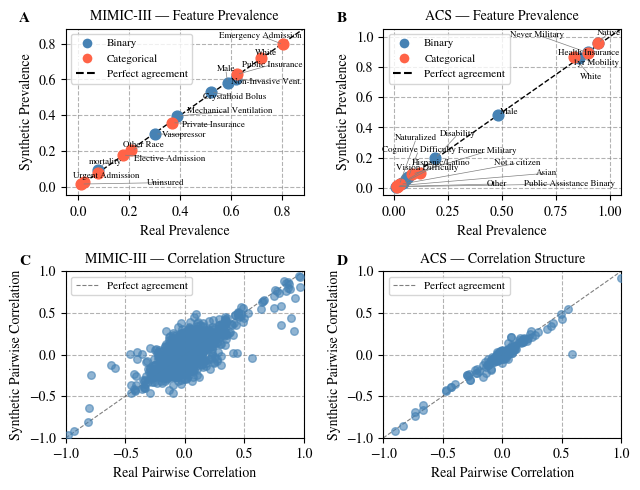

Saved fidelity_supplement.png


In [59]:
import matplotlib
matplotlib.rcParams['font.family'] = 'STIXGeneral'

from adjustText import adjust_text
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import os

RENAME_COLS = {
    'crystalloid_bolus': 'Crystalloid Bolus',
    'nivdurations':      'Non-Invasive Vent.',
    'vent': 'Mechanical Ventilation',
    'vaso': 'Vasopressor'
}

EXCLUDE_LABELS = {'Two or More', 'Current Military', 'Institutionalized', 'Black/African American', 'Born Citizen', 'Hearing Difficulty'}

OFFSET_OVERRIDE = {
    'Vision Difficulty': (0.02, 0.02),
}
def plot_fidelity_supplement(
    H_mimic,
    H_acs,
    res_mimic,
    res_acs,
    num_cols_subset_mimic=None,
    num_cols_subset_acs=None,
    figsize=(6.5, 5.0),
    out_dir='figures',
):
    os.makedirs(out_dir, exist_ok=True)

    def load_data(H, res, rename=False):
        cols    = H.NUM_COLS + H.BIN_COLS + H.CAT_COLS
        df_real = pd.read_csv(f"{H.DATA_PATH}/unnormalized_val.csv")[cols]
        syn_path = next(
            (r['syn_path'] for r in res['penalized']
             if r.get('syn_path') and os.path.exists(r['syn_path'])),
            None
        )
        if syn_path is None:
            raise ValueError("No synthetic path found for penalized model.")
        df_syn = pd.read_csv(syn_path)[cols]

        bin_cols = list(H.BIN_COLS)
        cat_cols = list(H.CAT_COLS)

        if rename:
            df_real  = df_real.rename(columns=RENAME_COLS)
            df_syn   = df_syn.rename(columns=RENAME_COLS)
            bin_cols = [RENAME_COLS.get(c, c) for c in bin_cols]
            cat_cols = [RENAME_COLS.get(c, c) for c in cat_cols]

        return df_real, df_syn, bin_cols, cat_cols

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.subplots_adjust(hspace=0.4, wspace=0.35)

    panel_labels = [['A', 'B'], ['C', 'D']]
    for row in range(2):
        for col in range(2):
            axes[row, col].text(
                -0.15, 1.1, panel_labels[row][col],
                transform=axes[row, col].transAxes,
                fontsize=11, fontweight='bold', va='top', ha='right'
            )

    for col_idx, (H, res, dataset_label, num_cols_subset) in enumerate([
        (H_mimic, res_mimic, 'MIMIC-III', num_cols_subset_mimic or H_mimic.NUM_COLS),
        (H_acs,   res_acs,   'ACS',       num_cols_subset_acs   or H_acs.NUM_COLS),
    ]):
        df_real, df_syn, bin_cols, cat_cols = load_data(
            H, res, rename=(dataset_label == 'MIMIC-III')
        )

        # Row 1: Prevalence scatter
        ax_prev     = axes[0, col_idx]
        prev_cols   = bin_cols + cat_cols
        colors_prev = ['steelblue'] * len(bin_cols) + ['tomato'] * len(cat_cols)

        real_prevs = [df_real[col].mean() for col in prev_cols]
        syn_prevs  = [df_syn[col].mean()  for col in prev_cols]

        lim_max = max(max(real_prevs), max(syn_prevs)) * 1.1
        ax_prev.set_xlim(0, lim_max)
        ax_prev.set_ylim(0, lim_max)
        ax_prev.set_axisbelow(True)
        ax_prev.grid(True, linestyle='--', alpha=0.6, color='gray')

        ax_prev.plot([0, lim_max], [0, lim_max], 'k--', linewidth=1, zorder=2)

        texts = []
        for x, y, col, c in zip(real_prevs, syn_prevs, prev_cols, colors_prev):
            ax_prev.scatter(x, y, color=c, s=60, zorder=3)
            if col in EXCLUDE_LABELS:
                continue
            dx, dy = OFFSET_OVERRIDE.get(col, (0, 0))
            t = ax_prev.text(x + dx, y + dy, col, fontsize=6.5, zorder=5)
            texts.append(t)

        adjust_text(
            texts,
            ax=ax_prev,
            arrowprops=dict(arrowstyle='-', color='gray', lw=0.5),
            expand_points=(4.0, 4.0),
            expand_text=(2.0, 2.0),
            force_points=(0.8, 1.6),
            force_text=(0.5, 0.5),
            force_pull=(0.02, 0.02),
            lim=2000,
            only_move={'points': 'xy', 'texts': 'xy'},
            avoid_self=True,
            x_lim=(0, lim_max),
            y_lim=(0, lim_max),
        )

        for t in texts:
            t.set_zorder(5)

        ax_prev.set_xlim(-0.05, lim_max)
        ax_prev.set_ylim(-0.05, lim_max)
        ax_prev.set_xlabel('Real Prevalence', fontsize=10)
        ax_prev.set_ylabel('Synthetic Prevalence', fontsize=10)
        ax_prev.set_title(f'{dataset_label} — Feature Prevalence', fontsize=10)
        ax_prev.tick_params(axis='both', labelsize=10)

        legend_elements = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue',
                   markersize=8, label='Binary'),
            Line2D([0], [0], marker='o', color='w', markerfacecolor='tomato',
                   markersize=8, label='Categorical'),
            Line2D([0], [0], linestyle='--', color='k', label='Perfect agreement'),
        ]
        ax_prev.legend(handles=legend_elements, fontsize=8)

        # Row 2: Pairwise correlation scatter
        ax_corr    = axes[1, col_idx]
        corr_real  = df_real.corr()
        corr_syn   = df_syn.corr()
        triu_idx   = np.triu_indices_from(corr_real.values, k=1)
        real_corrs = corr_real.values[triu_idx]
        syn_corrs  = corr_syn.values[triu_idx]

        ax_corr.set_axisbelow(True)
        ax_corr.grid(True, linestyle='--', alpha=0.6, color='gray')
        ax_corr.scatter(real_corrs, syn_corrs,
                        color='steelblue', alpha=0.6, s=30, zorder=3)
        ax_corr.plot([-1, 1], [-1, 1], 'k--', linewidth=0.8, alpha=0.5,
                     label='Perfect agreement')
        ax_corr.set_xlim(-1, 1)
        ax_corr.set_ylim(-1, 1)
        ax_corr.set_xlabel('Real Pairwise Correlation', fontsize=10)
        ax_corr.set_ylabel('Synthetic Pairwise Correlation', fontsize=10)
        ax_corr.set_title(f'{dataset_label} — Correlation Structure', fontsize=10)
        ax_corr.tick_params(axis='both', labelsize=10)
        ax_corr.legend(fontsize=8)

    plt.tight_layout()
    fname = 'fidelity_supplement.png'
    fig.savefig(fname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved {fname}")


plot_fidelity_supplement(
    H_mimic, H_acs,
    res_mimic=res_mimic,
    res_acs=res_acs,
    num_cols_subset_mimic=None,
    num_cols_subset_acs=None,
)

## Table 2 - main result

In [60]:


# This is now dataset-dependent for syn_model_auc — handle in best_idx call
HIGHER_IS_BETTER = {
    'cwc':          False,
    'dwd':          False,
    's2r_auc':      True,
    'mia_auc':      None,
    'syn_model_auc': True,   # overridden per dataset below
    'coef_corr':    True,
    'reg_mae':      False,
}

def agg_rmse(records, key):
    """Like agg() but takes sqrt of mean MSE for RMSE."""
    vals = [r[key] for r in records if r.get(key) is not None]
    if not vals:
        return None, None
    # sqrt(mean(MSE)) — conservative estimate of RMSE
    mean = float(np.sqrt(np.nanmean(vals)))
    std  = float(np.nanstd(np.sqrt(np.array(vals)))) if len(vals) > 1 else float('nan')
    return mean, std

# Metrics that need RMSE transformation
RMSE_METRICS = {'syn_model_auc'}  # rename to syn_model_metric for clarity

DISPLAY_NAMES_ABBREV = {
    'cwc':           r'CWC $\downarrow$',
    'dwd':           r'DWD $\downarrow$',
    's2r_auc':       r'S2R AUC $\uparrow$',
    'mia_auc':       r'MIA AUC',
    'syn_model_auc': r'Reg. Perf.$^\dagger$',  # no arrow, dagger for footnote
    'coef_corr':     r'Coef $r$ $\uparrow$',
}

# Dataset-specific display names for syn_model_auc
SYN_MODEL_DISPLAY = {
    'MIMIC': (r'Reg AUC $\uparrow$', False, False),  # (label, rmse, higher_is_better)
    'ACS':   (r'Reg RMSE $\downarrow$', True, False),
}

def best_idx(values, metric):
    """Return index of best value for a given metric."""
    clean = [(i, v) for i, v in enumerate(values) if v is not None and not np.isnan(v)]
    if not clean:
        return None
    if HIGHER_IS_BETTER.get(metric) is True:
        return max(clean, key=lambda x: x[1])[0]
    elif HIGHER_IS_BETTER.get(metric) is False:
        return min(clean, key=lambda x: x[1])[0]
    elif HIGHER_IS_BETTER.get(metric) is None:  # MIA — closest to 0.5
        return min(clean, key=lambda x: abs(x[1] - 0.5))[0]
    return None



def make_table1_combined(res_by_dataset, caption="Main Results", label="tab:main"):
    """CTGAN, TVAE, RLSyn — standard metrics, paneled by dataset."""
    models = ['ctgan', 'tvae', 'penalized']
    metric_order = [
        ('cwc',     'Fidelity'),
        ('dwd',     'Fidelity'),
        ('s2r_auc', 'ML Utility'),
        ('mia_auc', 'Privacy'),
    ]

    section_spans = {}
    for metric, section in metric_order:
        section_spans.setdefault(section, []).append(metric)

    section_header = []
    metric_header  = []
    for section, metrics in section_spans.items():
        section_header.append(
            f'\\multicolumn{{{len(metrics)}}}{{c}}{{\\textit{{{section}}}}}'
        )
        for m in metrics:
            metric_header.append(DISPLAY_NAMES.get(m, m))

    n_metric_cols = len(metric_order)

    lines = [
        r'\begin{table}[ht]',
        r'\centering',
        r'\small',
        f'\\caption{{{caption}}}',
        f'\\label{{{label}}}',
        r'\begin{tabular}{l' + 'c' * n_metric_cols + '}',
        r'\toprule',
        'Model & ' + ' & '.join(section_header) + r' \\',
        '& '      + ' & '.join(metric_header)   + r' \\',
        r'\midrule',
    ]

    for d_idx, (dataset, res) in enumerate(res_by_dataset.items()):
        cfg = DATASET_CONFIG[dataset]

        # Panel header
        lines.append(
            f'\\multicolumn{{{n_metric_cols + 1}}}{{l}}'
            f'{{\\textbf{{{cfg["label"]}}}}} \\\\'
        )

        

        # Collect means per metric for bolding
        model_means = {
            metric: [agg(res[model], metric)[0] for model in models]
            for metric, _ in metric_order
        }

        for m_idx, model in enumerate(models):
            cells = []
            for metric, _ in metric_order:
                mean, std = agg(res[model], metric)
                cell = fmt(mean, std)
                if best_idx(model_means[metric], metric) == m_idx:
                    cell = f'\\textbf{{{cell}}}'
                cells.append(cell)
            lines.append(
                r'\quad ' + COL_LABELS[model] + ' & ' +
                ' & '.join(cells) + r' \\'
            )
        if d_idx < len(res_by_dataset) - 1:
            lines.append(r'\midrule')

    lines += [r'\bottomrule', r'\end{tabular}', r'\end{table}']
    return '\n'.join(lines)


def make_table2_combined(res_by_dataset, caption="Ablation: Effect of Regression Reward", label="tab:ablation"):
    models = ['unpenalized', 'penalized']
    metric_order = [
        ('cwc',          'Fidelity'),
        ('dwd',          'Fidelity'),
        ('mia_auc',      'Privacy'),
        ('syn_model_auc','Sci. Utility'),
        ('coef_corr',    'Sci. Utility'),
    ]

    section_spans = {}
    for metric, section in metric_order:
        section_spans.setdefault(section, []).append(metric)

    n_metric_cols = len(metric_order)

    lines = [
        r'\begin{table}[ht]',
        r'\centering',
        r'\small',
        f'\\caption{{{caption}}}',
        f'\\label{{{label}}}',
        r'\resizebox{\textwidth}{!}{',
        r'\begin{tabular}{l' + 'c' * n_metric_cols + '}',
        r'\toprule',
    ]

    def normalize_cwc(mean, std, records):
        """Divide CWC by C(n_features, 2) computed from stored n_features."""
        n_features = next(
            (r.get('n_features') for r in records if r.get('n_features') is not None),
            None
        )
        if n_features is None:
            return mean, std
        norm = 1e6 # = n_features * (n_features - 1) / 2
        mean = mean / norm if mean is not None else None
        std  = std  / norm if std is not None and not np.isnan(std) else std
        return mean, std

    for d_idx, (dataset, res) in enumerate(res_by_dataset.items()):
        cfg = DATASET_CONFIG[dataset]
        syn_label, use_rmse, syn_higher = SYN_MODEL_DISPLAY[dataset]

        # All records for this dataset across all models
        all_records = [r for m in models for r in res[m]]

        def get_display(m):
            if m == 'syn_model_auc':
                return syn_label
            return DISPLAY_NAMES_ABBREV.get(m, m)

        section_header = []
        metric_header  = []
        for section, metrics in section_spans.items():
            section_header.append(
                f'\\multicolumn{{{len(metrics)}}}{{c}}{{\\textit{{{section}}}}}'
            )
            for m in metrics:
                metric_header.append(get_display(m))

        if d_idx == 0:
            lines.append('Model & ' + ' & '.join(section_header) + r' \\')
            metric_header_marked = []
            for m, _ in metric_order:
                if m == 'syn_model_auc':
                    metric_header_marked.append(get_display(m) + r'$^\dagger$')
                else:
                    metric_header_marked.append(get_display(m))
            lines.append('& ' + ' & '.join(metric_header_marked) + r' \\')
            lines.append(r'\midrule')

        # Panel header
        lines.append(
            f'\\multicolumn{{{n_metric_cols + 1}}}{{l}}'
            f'{{\\textbf{{{cfg["label"]}}}}} \\\\'
        )

        # Higher is better for syn_model_auc depends on dataset
        hib_override = {**HIGHER_IS_BETTER, 'syn_model_auc': syn_higher}

        def best_idx_local(values, metric):
            clean = [(i, v) for i, v in enumerate(values) if v is not None and not np.isnan(v)]
            if not clean:
                return None
            if hib_override.get(metric) is True:
                return max(clean, key=lambda x: x[1])[0]
            elif hib_override.get(metric) is False:
                return min(clean, key=lambda x: x[1])[0]
            elif hib_override.get(metric) is None:
                return min(clean, key=lambda x: abs(x[1] - 0.5))[0]
            return None

        def get_mean_std(metric, records):
            """Get mean/std for a metric, applying any necessary transforms."""
            agg_fn = agg_rmse if (metric == 'syn_model_auc' and use_rmse) else agg
            mean, std = agg_fn(records, metric)
            if metric == 'cwc':
                mean, std = normalize_cwc(mean, std, records)
            return mean, std

        # Baseline row
        baseline_cells = []
        for metric, _ in metric_order:
            baseline_key = METRIC_TO_BASELINE.get(metric)
            if baseline_key and DATASET_CONFIG[dataset].get(baseline_key, (None,))[0] is not None:
                b_m, b_s = DATASET_CONFIG[dataset][baseline_key]
                if metric == 'syn_model_auc' and use_rmse and b_m is not None:
                    b_m = float(np.sqrt(b_m))
                if metric == 'cwc':
                    b_m, b_s = normalize_cwc(b_m, b_s, all_records)
                baseline_cells.append(fmt(b_m, b_s, baseline=True))
            else:
                baseline_cells.append('---')
        lines.append(
            r'\quad\textit{Real Data} & ' +
            ' & '.join(baseline_cells) + r' \\'
        )

        # Collect means for bolding
        model_means = {
            metric: [get_mean_std(metric, res[model])[0] for model in models]
            for metric, _ in metric_order
        }

        # Model rows
        for m_idx, model in enumerate(models):
            cells = []
            for metric, _ in metric_order:
                mean, std = get_mean_std(metric, res[model])
                cell = fmt(mean, std)
                if best_idx_local(model_means[metric], metric) == m_idx:
                    cell = f'\\textbf{{{cell}}}'
                cells.append(cell)
            lines.append(
                r'\quad ' + COL_LABELS[model] + ' & ' +
                ' & '.join(cells) + r' \\'
            )

        if d_idx < len(res_by_dataset) - 1:
            lines.append(r'\midrule')

    lines += [r'\bottomrule', r'\end{tabular}', r'}', r'\end{table}']
    return '\n'.join(lines)


# Usage:
res_by_dataset = {
    'MIMIC': res_mimic,    # your existing res dict
    'ACS':   res_acs # populate when ready
}

#print("% ---- TABLE 1 ----")
#print(make_table1_combined(res_by_dataset))
print("\n% ---- TABLE 2 ----")
print(make_table2_combined(
    res_by_dataset,
    caption=r"Ablation: Effect of Regression Reward. $^\dagger$Regression performance is measured as AUC ($\uparrow$) for MIMIC-III and RMSE ($\downarrow$) for ACS.",
    label="tab:ablation"
))


% ---- TABLE 2 ----
\begin{table}[ht]
\centering
\small
\caption{Ablation: Effect of Regression Reward. $^\dagger$Regression performance is measured as AUC ($\uparrow$) for MIMIC-III and RMSE ($\downarrow$) for ACS.}
\label{tab:ablation}
\resizebox{\textwidth}{!}{
\begin{tabular}{lccccc}
\toprule
Model & \multicolumn{2}{c}{\textit{Fidelity}} & \multicolumn{1}{c}{\textit{Privacy}} & \multicolumn{2}{c}{\textit{Sci. Utility}} \\
& CWC $\downarrow$ & DWD $\downarrow$ & MIA AUC & Reg AUC $\uparrow$$^\dagger$ & Coef $r$ $\uparrow$ \\
\midrule
\multicolumn{6}{l}{\textbf{MIMIC-III}} \\
\quad\textit{Real Data} & \textit{0.000} & \textit{0.206} & \textit{1.000} & \textit{0.851} & --- \\
\quad \textsc{RLSyn} & \textbf{0.000 $\pm$ 0.000} & \textbf{0.006 $\pm$ 0.000} & \textbf{0.500 $\pm$ 0.002} & \textbf{0.765 $\pm$ 0.008} & 0.054 $\pm$ 0.110 \\
\quad \textsc{RLSyn+Reg} & 0.000 & 0.007 $\pm$ 0.000 & 0.502 $\pm$ 0.005 & 0.835 $\pm$ 0.005 & \textbf{0.600 $\pm$ 0.062} \\
\midrule
\multicolumn{6}{l}{

## Figure 2 - Sensitivity Analysis

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

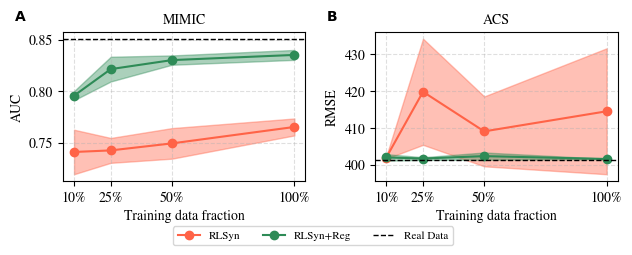

In [61]:
import matplotlib
#matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.serif'] = ['Times New Roman']
 
SENSITIVITY_METRIC_CONFIG = {
    'coef_corr':    {'label': 'Coefficient Correlation ($r$)', 'rmse': False, 'higher': True},
    'syn_model_auc': {
        'MIMIC': {'label': 'AUC',  'rmse': False, 'higher': True},
        'ACS':   {'label': 'RMSE', 'rmse': True,  'higher': False},
    },
    's2r_auc':      {'label': 'S2R AUC', 'rmse': False, 'higher': True},
    'dwd':          {'label': 'DWD',     'rmse': False, 'higher': False},
}

def plot_sensitivity(res_by_frac, dataset, metric='coef_corr', out_dir=''):
    fracs  = sorted(res_by_frac.keys())
    models = ['unpenalized', 'penalized']
    colors = {'unpenalized': 'tomato', 'penalized': 'seagreen'}

    cfg = SENSITIVITY_METRIC_CONFIG.get(metric, {})
    if isinstance(cfg.get('MIMIC'), dict):
        cfg = cfg[dataset]
    use_rmse = cfg.get('rmse', False)
    ylabel   = cfg.get('label', metric)

    ax = plt.gca()

    for model in models:
        agg_fn = agg_rmse if use_rmse else agg
        means = [agg_fn(res_by_frac[f][model], metric)[0] for f in fracs]
        stds  = [agg_fn(res_by_frac[f][model], metric)[1] for f in fracs]
        means = np.array([m if m is not None else np.nan for m in means])
        stds  = np.array([s if s is not None and not np.isnan(s) else 0 for s in stds])

        ax.plot(fracs, means, marker='o',
                label=COL_LABELS[model].replace('\\textsc{', '').replace('}', ''),
                color=colors[model])
        ax.fill_between(fracs, means - stds, means + stds,
                        alpha=0.4, color=colors[model])

    baseline_key = METRIC_TO_BASELINE.get(metric)
    if baseline_key and DATASET_CONFIG[dataset].get(baseline_key, (None,))[0] is not None:
        b_m, b_s = DATASET_CONFIG[dataset][baseline_key]
        if use_rmse and b_m is not None:
            b_m = float(np.sqrt(b_m))
        ax.axhline(b_m, color='black', linestyle='--', linewidth=1.0,
                   label='Real Data', zorder=2)
        if b_s and not np.isnan(b_s) and b_s > 0:
            ax.axhspan(b_m - b_s, b_m + b_s, alpha=0.08, color='black')

    ax.set_xlabel('Training data fraction', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(dataset, fontsize=10)
    ax.set_xticks(fracs)
    ax.set_xticklabels([f'{int(f*100)}%' for f in fracs], fontsize=10)
    ax.tick_params(axis='y', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)

fig = plt.figure(figsize=(6.5, 2.5))

ax1 = plt.subplot(1, 2, 1)
plot_sensitivity(res_mimic_by_frac, 'MIMIC', metric='syn_model_auc')
ax1.text(-0.2, 1.15, 'A', transform=ax1.transAxes,
         fontsize=10, fontweight='bold', fontfamily='serif', va='top')

ax2 = plt.subplot(1, 2, 2)
plot_sensitivity(res_acs_by_frac, 'ACS', metric='syn_model_auc')
ax2.text(-0.2, 1.15, 'B', transform=ax2.transAxes,
         fontsize=10, fontweight='bold', fontfamily='serif', va='top')

handles, labels = plt.gca().get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3,
           fontsize=8, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig('sensitivity_analysis.png', bbox_inches='tight', dpi=300)

## Fairness

In [62]:
from RL.evaluation import *
def fairness_analysis(df_train, df_syn_base, df_syn_pen, df_test, DATASET):
    """
    Compare predictive fairness of regression models trained on:
    - real data
    - unpenalized synthetic data
    - penalized synthetic data
    Evaluated on held-out real test set, stratified by subgroup.
    """
    if DATASET == 'MIMIC':
        fit_fn  = fit_mimic_regression
        eval_fn = eval_mimic_regression
        subgroups = {
            'Overall':               None,
            'White': 'White',
            'Black/African American': 'Black/African American',
            'Other Race':             'Other Race',
        }
    else:
        fit_fn  = fit_acs_regression
        eval_fn = eval_acs_regression
        subgroups = {
            'Overall':               None,
            'Black/African American': 'Black/African American',
            'Other Race':             'Other',
            'Two or More':            'Two or More',
        }

    # Fit the three models
    model_real, _ = fit_fn(df_train)
    model_base, _ = fit_fn(df_syn_base)
    model_pen,  _ = fit_fn(df_syn_pen)

    rows = []
    for subgroup_label, subgroup_col in subgroups.items():
        # Filter test set to subgroup
        if subgroup_col is None:
            df_sub = df_test
        else:
            df_sub = df_test[df_test[subgroup_col] > 0.5]

        if len(df_sub) < 30:
            print(f"  Skipping {subgroup_label} — only {len(df_sub)} test samples")
            continue

        row = {
            'subgroup': subgroup_label,
            'n_test':   len(df_sub),
        }
        for label, model in [('real', model_real),
                              ('base', model_base),
                              ('pen',  model_pen)]:
            if model is not None:
                row[f'metric_{label}'] = eval_fn(model, df_sub)
            else:
                row[f'metric_{label}'] = None

        rows.append(row)

    df = pd.DataFrame(rows)

    metric_name = 'AUC' if DATASET == 'MIMIC' else 'MSE'
    print(f"\n{'='*70}")
    print(f"Fairness Analysis — {metric_name} on held-out real test set ({DATASET})")
    print(f"{'='*70}")
    print(f"{'Subgroup':30s} {'n_test':>8} {'Real':>10} {'RLSyn':>10} {'RLSyn+Reg':>12}")
    print('-'*70)
    for _, row in df.iterrows():
        print(f"{row['subgroup']:30s} {row['n_test']:>8} "
              f"{row['metric_real']:>10.4f} "
              f"{row['metric_base']:>10.4f} "
              f"{row['metric_pen']:>12.4f}")

    #df.to_csv(Path(H.OUT_DIR) / f"fairness_{DATASET.lower()}.csv", index=False)
    return df

In [63]:
df_train = pd.read_csv('preprocessing/MIMIC/data/unnormalized_train.csv', index_col=0)
df_test = pd.read_csv('preprocessing/MIMIC/data/unnormalized_test.csv', index_col=0)
df_syn_base = pd.read_csv('MIMIC/results/50/synthetic_rescaled.csv', index_col=0)
df_syn_pen = pd.read_csv('MIMIC/results/penalized/50/synthetic_rescaled.csv', index_col=0)

res = fairness_analysis(df_train, df_syn_base, df_syn_pen, df_test, "MIMIC")

ValueError: shapes (218,13) and (14,) not aligned: 13 (dim 1) != 14 (dim 0)

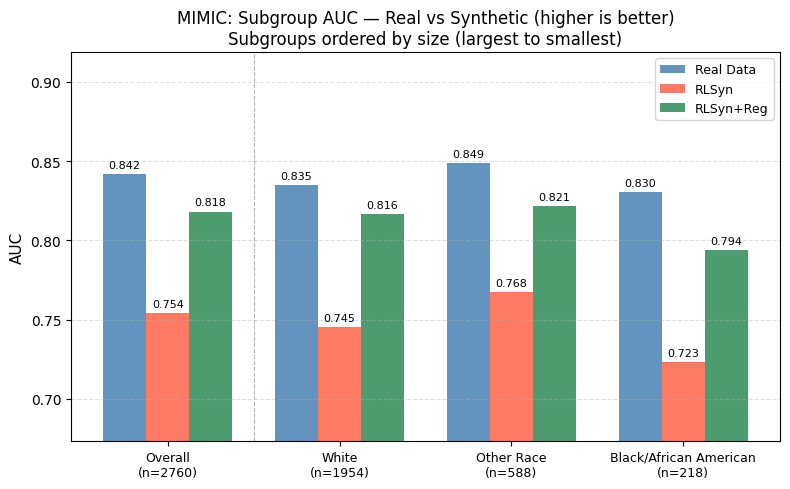

In [ ]:
def plot_fairness(df_fairness, DATASET, out_dir):
    metric_name = 'AUC' if DATASET == 'MIMIC' else 'MSE'
    higher_is_better = DATASET == 'MIMIC'

    # Sort by group size descending (largest first)
    df_fairness = df_fairness.copy()
    # Keep Overall first, then sort remaining by n_test descending
    df_overall = df_fairness[df_fairness['subgroup'] == 'Overall']
    df_subgroups = df_fairness[df_fairness['subgroup'] != 'Overall'].sort_values(
        'n_test', ascending=False
    )
    df_fairness = pd.concat([df_overall, df_subgroups]).reset_index(drop=True)

    subgroups = df_fairness['subgroup'].tolist()
    x = np.arange(len(subgroups))
    width = 0.25

    fig, ax = plt.subplots(figsize=(max(6, len(subgroups) * 2), 5))

    bars_real = ax.bar(x - width, df_fairness['metric_real'], width,
                       label='Real Data', color='steelblue', alpha=0.85)
    bars_base = ax.bar(x,          df_fairness['metric_base'], width,
                       label='RLSyn', color='tomato', alpha=0.85)
    bars_pen  = ax.bar(x + width,  df_fairness['metric_pen'],  width,
                       label='RLSyn-Reg', color='seagreen', alpha=0.85)

    # Value labels on bars
    for bars in [bars_real, bars_base, bars_pen]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3), textcoords='offset points',
                        ha='center', va='bottom', fontsize=8)

    # Add n_test as x-axis sublabel
    xtick_labels = [
        f"{row['subgroup']}\n(n={row['n_test']})"
        for _, row in df_fairness.iterrows()
    ]

    # Vertical divider between Overall and subgroups
    ax.axvline(0.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.6)

    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, fontsize=9)
    ax.set_ylabel(metric_name, fontsize=11)
    ax.set_title(f'{DATASET}: Subgroup {metric_name} — Real vs Synthetic '
                 f'({"higher" if higher_is_better else "lower"} is better)\n'
                 f'Subgroups ordered by size (largest to smallest)',
                 fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

    # Set y-axis to start just below the minimum value for readability
    all_vals = pd.concat([df_fairness['metric_real'],
                          df_fairness['metric_base'],
                          df_fairness['metric_pen']]).dropna()
    ax.set_ylim(max(0, all_vals.min() - 0.05), all_vals.max() + 0.07)

    fig.tight_layout()
    path = Path(out_dir) / f"fairness_{DATASET.lower()}.png"
    #fig.savefig(path, dpi=150, bbox_inches='tight')
    #plt.close(fig)
    #print(f"Saved {path}")

plot_fairness(res, 'MIMIC', '')

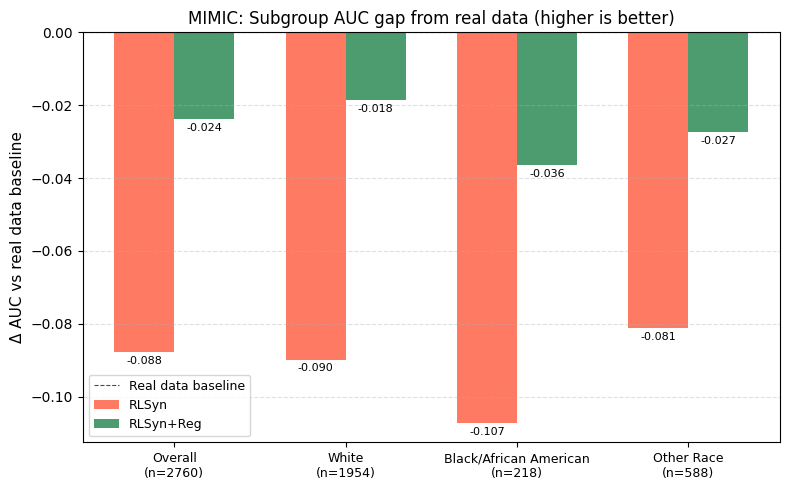

In [ ]:
def plot_fairness_delta(df_fairness, DATASET, out_dir):
    """Plot performance relative to real data baseline."""
    metric_name = 'AUC' if DATASET == 'MIMIC' else 'MSE'
    higher_is_better = DATASET == 'MIMIC'

    subgroups = df_fairness['subgroup'].tolist()
    x = np.arange(len(subgroups))
    width = 0.35

    # Compute delta from real data baseline
    df_fairness = df_fairness.copy()
    df_fairness['delta_base'] = df_fairness['metric_base'] - df_fairness['metric_real']
    df_fairness['delta_pen']  = df_fairness['metric_pen']  - df_fairness['metric_real']

    fig, ax = plt.subplots(figsize=(max(6, len(subgroups) * 2), 5))

    bars_base = ax.bar(x - width/2, df_fairness['delta_base'], width,
                       label='RLSyn', color='tomato', alpha=0.85)
    bars_pen  = ax.bar(x + width/2, df_fairness['delta_pen'],  width,
                       label='RLSyn+Reg', color='seagreen', alpha=0.85)

    # Value labels
    for bars in [bars_base, bars_pen]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:+.3f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3 if height >= 0 else -10),
                        textcoords='offset points',
                        ha='center', va='bottom', fontsize=8)

    xtick_labels = [
        f"{row['subgroup']}\n(n={row['n_test']})"
        for _, row in df_fairness.iterrows()
    ]

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7,
               label='Real data baseline')
    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, fontsize=9)
    ax.set_ylabel(f'Δ {metric_name} vs real data baseline', fontsize=11)
    ax.set_title(f'{DATASET}: Subgroup {metric_name} gap from real data '
                 f'({"higher" if higher_is_better else "lower"} is better)',
                 fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

    fig.tight_layout()
    path = Path(out_dir) / f"fairness_delta_{DATASET.lower()}.png"
    #fig.savefig(path, dpi=150, bbox_inches='tight')
    #plt.close(fig)
    #print(f"Saved {path}")

plot_fairness_delta(res, 'MIMIC', '')

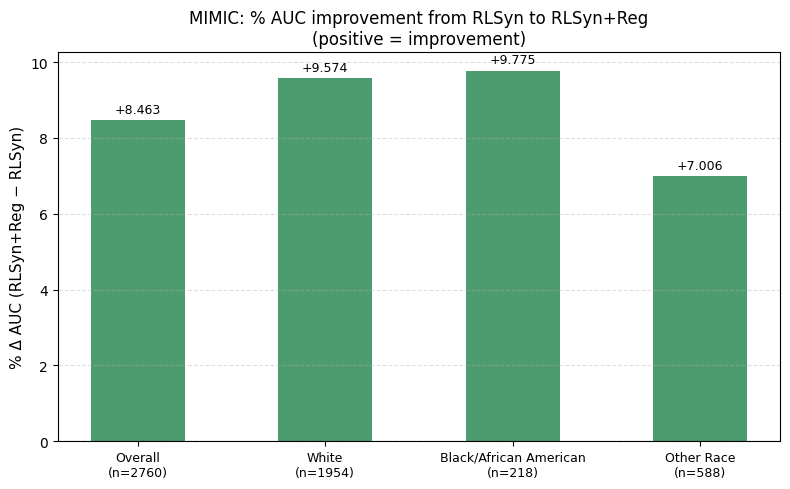

In [ ]:
def plot_fairness_improvement(df_fairness, DATASET, out_dir):
    """Plot AUC improvement from RLSyn to RLSyn-REG per subgroup."""
    metric_name = 'AUC' if DATASET == 'MIMIC' else 'MSE'
    higher_is_better = DATASET == 'MIMIC'

    df_fairness = df_fairness.copy()
    df_fairness['improvement'] = (
        (df_fairness['metric_pen'] - df_fairness['metric_base']) 
        / df_fairness['metric_base'].abs() * 100
    )
    subgroups = df_fairness['subgroup'].tolist()
    x = np.arange(len(subgroups))

    fig, ax = plt.subplots(figsize=(max(6, len(subgroups) * 2), 5))

    colors = ['seagreen' if v >= 0 else 'tomato'
              for v in df_fairness['improvement']]
    bars = ax.bar(x, df_fairness['improvement'], color=colors, alpha=0.85, width=0.5)

    for bar in bars:
        height = bar.get_height()
        ax.annotate(f'{height:+.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, 3 if height >= 0 else -10),
                    textcoords='offset points',
                    ha='center', va='bottom', fontsize=9)

    xtick_labels = [
        f"{row['subgroup']}\n(n={row['n_test']})"
        for _, row in df_fairness.iterrows()
    ]

    ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(xtick_labels, fontsize=9)
    ax.set_ylabel(f'% Δ {metric_name} (RLSyn-REG − RLSyn)', fontsize=11)
    ax.set_title(f'{DATASET}: % {metric_name} improvement from RLSyn to RLSyn-REG\n'
                f'({"positive" if higher_is_better else "negative"} = improvement)',
                fontsize=12)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)

    fig.tight_layout()
    path = Path(out_dir) / f"fairness_improvement_{DATASET.lower()}.png"
    #fig.savefig(path, dpi=150, bbox_inches='tight')
    #plt.close(fig)
    #print(f"Saved {path}")

plot_fairness_improvement(res, 'MIMIC', '')

## Figures for presentation

Real:      (22075, 83)
Synthetic: (22075, 83)


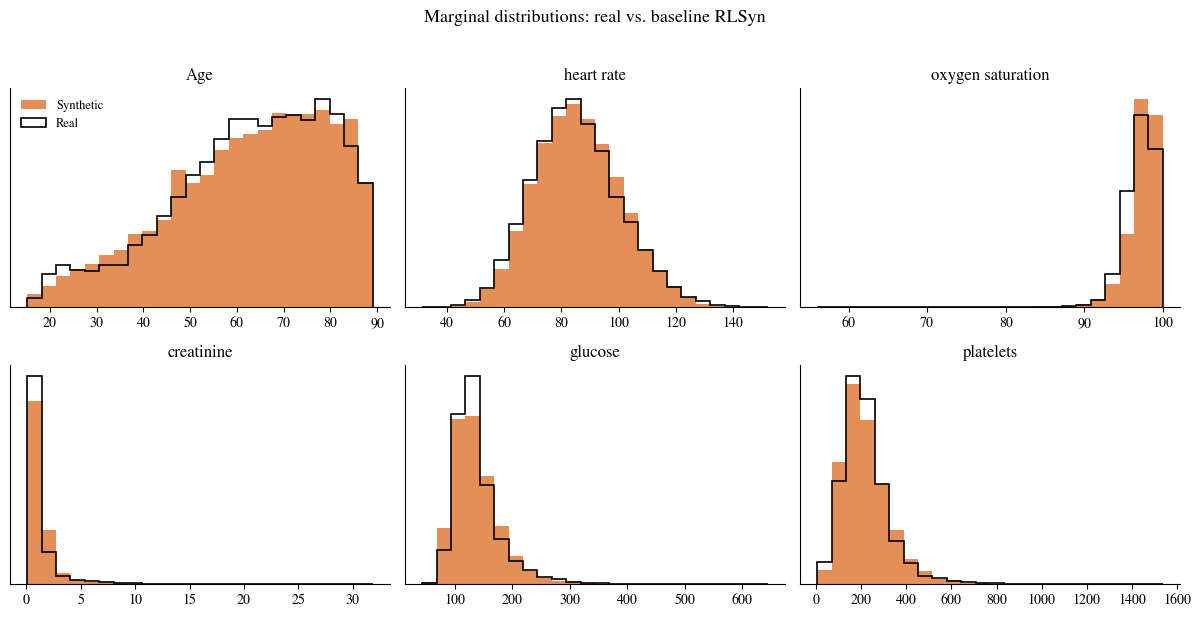

In [ ]:
# ============================================================
# Setup: paths and data loading
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Paths
REAL_DATA_PATH = "/home/nick/RL_guided/preprocessing/MIMIC/data/unnormalized_train.csv"
BASELINE_SYNTH_PATH = "/home/nick/RL_guided/MIMIC/results/50/synthetic_rescaled.csv"

# Load
real_df = pd.read_csv(REAL_DATA_PATH)
synth_df = pd.read_csv(BASELINE_SYNTH_PATH)

# Subsample synthetic to match real size for fair visual comparison
if len(synth_df) > len(real_df):
    synth_df = synth_df.sample(n=len(real_df), random_state=0).reset_index(drop=True)

print(f"Real:      {real_df.shape}")
print(f"Synthetic: {synth_df.shape}")

# ============================================================
# Figure 1: Marginal histograms — real vs. baseline RLSyn
# ============================================================

features_to_plot = [
    "Age",
    "heart rate",
    "oxygen saturation",
    "creatinine",
    "glucose",
    "platelets",
]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()

for ax, feat in zip(axes, features_to_plot):
    real_vals = real_df[feat].dropna()
    synth_vals = synth_df[feat].dropna()

    lo = min(real_vals.min(), synth_vals.min())
    hi = max(real_vals.max(), synth_vals.max())
    bins = np.linspace(lo, hi, 25)

    # Synthetic: filled, no border
    ax.hist(synth_vals, bins=bins, density=True,
            color="#E07B39", alpha=0.85, edgecolor="none", label="Synthetic")

    # Real: transparent fill, black outline
    ax.hist(real_vals, bins=bins, density=True,
            facecolor="none", edgecolor="black", linewidth=1.2,
            histtype="step", label="Real")

    ax.set_title(feat)
    ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

axes[0].legend(loc="upper left", fontsize=9, frameon=False)
fig.suptitle("Marginal distributions: real vs. baseline RLSyn", fontsize=13, y=1.02)
fig.tight_layout()
plt.show()

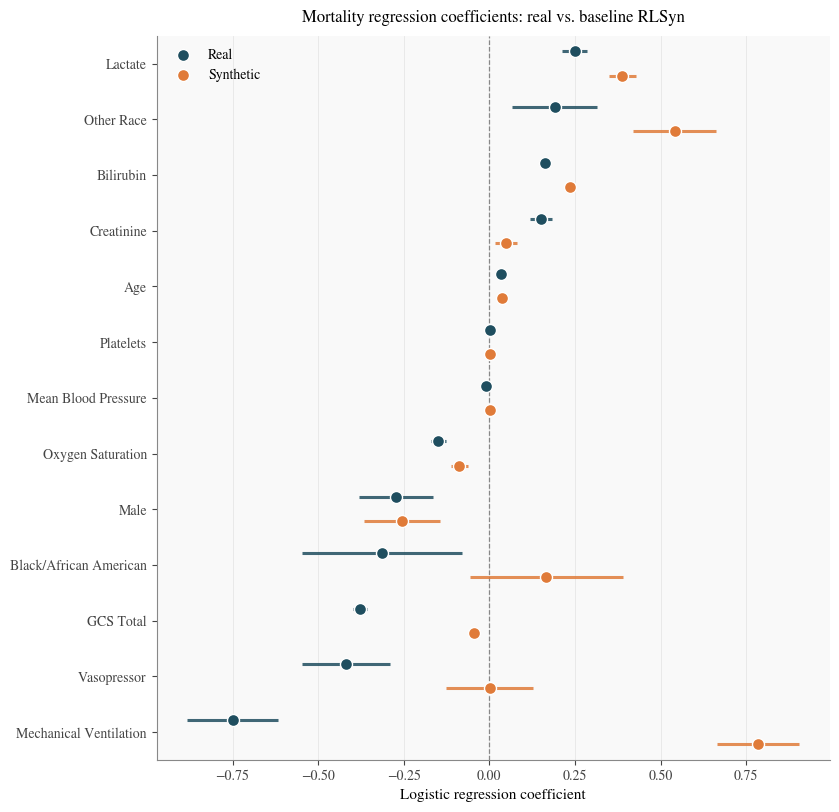

Coefficient correlation (real vs. RLSyn): -0.083


In [ ]:
# ============================================================
# Figure 2: Forest plot — real vs. baseline RLSyn (paper pipeline)
# ============================================================
import statsmodels.api as sm

def prepare_mimic(df):
    features_df = pd.DataFrame({
        'Oxygen Saturation': df['oxygen saturation'],
        'Mechanical Ventilation': df['vent'],
        'Mean Blood Pressure': df['mean blood pressure'],
        'Vasopressor': df['vaso'],
        'Lactate': df['lactate'],
        'Creatinine': df['creatinine'],
        'Platelets': df['platelets'],
        'Bilirubin': df['bilirubin'],
        'GCS Total': df['glascow coma scale total'],
        'Age': df['Age'],
        'Male': df['Male'],
        'Black/African American': df['Black/African American'],
        'Other Race': df['Other Race'],
    })
    return features_df, df['mortality']

def fit_logit(df):
    X, y = prepare_mimic(df)
    X = sm.add_constant(X, has_constant='add')
    model = sm.Logit(y, X).fit(disp=0)
    return model.params.drop('const'), model.conf_int().drop('const')

real_coefs, real_ci = fit_logit(real_df)
synth_coefs, synth_ci = fit_logit(synth_df)

shared = [f for f in real_coefs.index if f in synth_coefs.index]
order = real_coefs.loc[shared].sort_values().index
real_coefs = real_coefs.loc[order]
synth_coefs = synth_coefs.loc[order]
real_ci = real_ci.loc[order]
synth_ci = synth_ci.loc[order]

COLOR_REAL = "#1F4E5F"
COLOR_SYNTH = "#E07B39"

# Spacing: each feature gets a row centered at row_spacing * i
row_spacing = 1.15
offset = 0.25  # within-pair vertical separation

n = len(order)
y_centers = np.arange(n) * row_spacing

fig, ax = plt.subplots(figsize=(8.5, max(6.5, n * row_spacing * 0.55)))

ax.hlines(y_centers + offset, real_ci[0].values, real_ci[1].values,
          color=COLOR_REAL, linewidth=2.2, alpha=0.85, zorder=2)
ax.scatter(real_coefs.values, y_centers + offset,
           color=COLOR_REAL, s=75, zorder=4,
           edgecolor="white", linewidth=1.0, label="Real")

ax.hlines(y_centers - offset, synth_ci[0].values, synth_ci[1].values,
          color=COLOR_SYNTH, linewidth=2.2, alpha=0.85, zorder=2)
ax.scatter(synth_coefs.values, y_centers - offset,
           color=COLOR_SYNTH, s=75, zorder=4,
           edgecolor="white", linewidth=1.0, label="Synthetic")

# Faint horizontal band behind each pair to visually group them
for yc in y_centers:
    ax.axhspan(yc - row_spacing / 2, yc + row_spacing / 2,
               facecolor="#F5F5F5", alpha=0.5, zorder=0)

ax.axvline(0, color="#888888", linewidth=0.9, linestyle="--", zorder=1)

ax.set_yticks(y_centers)
ax.set_yticklabels(order, fontsize=10)
ax.set_ylim(y_centers[0] - row_spacing / 2, y_centers[-1] + row_spacing / 2)
ax.set_xlabel("Logistic regression coefficient", fontsize=11)
ax.set_title("Mortality regression coefficients: real vs. baseline RLSyn",
             fontsize=12, pad=10)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#888888")
ax.spines["bottom"].set_color("#888888")
ax.tick_params(colors="#444444")

ax.grid(axis="x", alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(loc="upper left", fontsize=10, frameon=False)

fig.tight_layout()
plt.show()

r = np.corrcoef(real_coefs.values, synth_coefs.values)[0, 1]
print(f"Coefficient correlation (real vs. RLSyn): {r:.3f}")

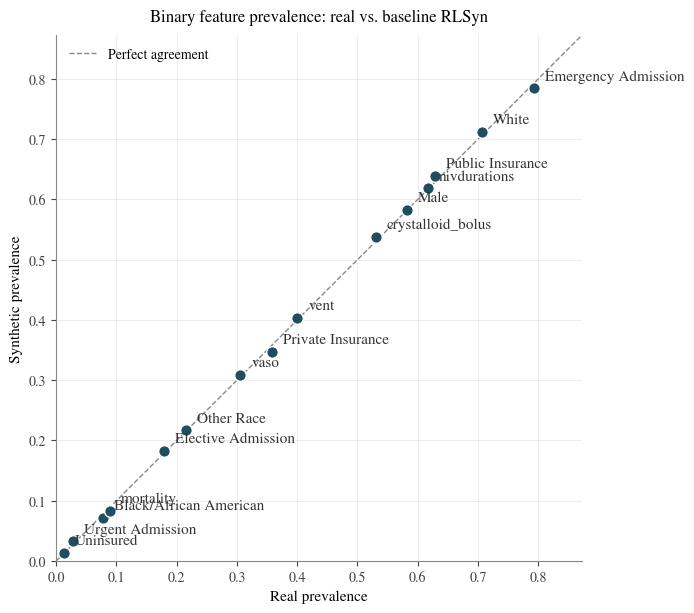

Mean absolute prevalence difference: 0.0050


In [ ]:
# ============================================================
# Figure 3: Real vs. synthetic prevalence for binary features
# ============================================================

# Binary features in the MIMIC dataset
binary_features = [
    "Male",
    "Black/African American",
    "White",
    "Other Race",
    "Private Insurance",
    "Public Insurance",
    "Uninsured",
    "Elective Admission",
    "Emergency Admission",
    "Urgent Admission",
    "mortality",
    "vent",
    "vaso",
    "crystalloid_bolus",
    "nivdurations",
]

# Compute prevalences
real_prev = real_df[binary_features].mean()
synth_prev = synth_df[binary_features].mean()

COLOR_POINT = "#1F4E5F"

fig, ax = plt.subplots(figsize=(7, 7))

# Diagonal reference line first so points sit on top
lim = max(real_prev.max(), synth_prev.max()) * 1.1
ax.plot([0, lim], [0, lim], linestyle="--", color="#888888",
        linewidth=1.0, label="Perfect agreement", zorder=1)

# Scatter points
ax.scatter(real_prev.values, synth_prev.values,
           color=COLOR_POINT, s=70, zorder=3,
           edgecolor="white", linewidth=1.0)

# Label each point — offset slightly to avoid covering markers
for feat in binary_features:
    ax.annotate(feat, (real_prev[feat], synth_prev[feat]),
                xytext=(8, 6), textcoords="offset points",
                fontsize=11, color="#333333")

ax.set_xlim(0, lim)
ax.set_ylim(0, lim)
ax.set_aspect("equal")
ax.set_xlabel("Real prevalence", fontsize=11)
ax.set_ylabel("Synthetic prevalence", fontsize=11)
ax.set_title("Binary feature prevalence: real vs. baseline RLSyn",
             fontsize=12, pad=10)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.spines["left"].set_color("#888888")
ax.spines["bottom"].set_color("#888888")
ax.tick_params(colors="#444444")

ax.grid(True, alpha=0.25, linewidth=0.6)
ax.set_axisbelow(True)
ax.legend(loc="upper left", fontsize=10, frameon=False)

fig.tight_layout()
plt.show()

# Mean absolute prevalence difference — a one-number summary
apd = np.mean(np.abs(real_prev.values - synth_prev.values))
print(f"Mean absolute prevalence difference: {apd:.4f}")

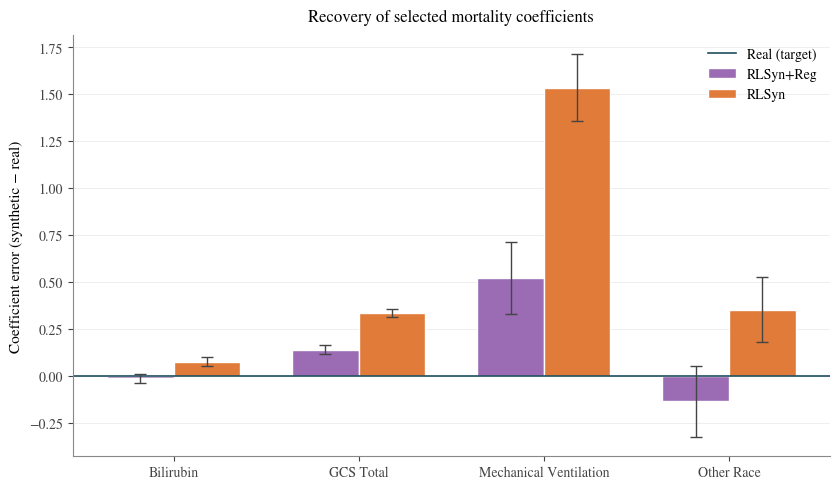

In [ ]:
# ============================================================
# Per-coefficient error from real, with 95% CIs
# ============================================================
PENALIZED_SYNTH_PATH = "/home/nick/RL_guided/MIMIC/results/penalized/50/synthetic_rescaled.csv"
penalized_df = pd.read_csv(PENALIZED_SYNTH_PATH)
if len(penalized_df) > len(real_df):
    penalized_df = penalized_df.sample(n=len(real_df), random_state=0).reset_index(drop=True)


def plot_coefficient_errors(real_model, synth_model, pen_model, 
                            features=("Bilirubin", "GCS Total",
                                      "Mechanical Ventilation", "Other Race")):
    """Bar chart of (synthetic - real) coefficient errors with 95% CIs."""

    COLOR_SYNTH = "#E07B39"
    COLOR_PEN = "#9B6BB3"
    Z = 1.96

    real_coefs = real_model.params
    real_se = real_model.bse
    synth_coefs = synth_model.params
    synth_se = synth_model.bse
    pen_coefs = pen_model.params
    pen_se = pen_model.bse

    pen_err = [pen_coefs[f] - real_coefs[f] for f in features]
    synth_err = [synth_coefs[f] - real_coefs[f] for f in features]

    pen_ci = [Z * np.sqrt(pen_se[f]**2 + real_se[f]**2) for f in features]
    synth_ci = [Z * np.sqrt(synth_se[f]**2 + real_se[f]**2) for f in features]

    x = np.arange(len(features))
    width = 0.36

    fig, ax = plt.subplots(figsize=(8.5, 5))

    ax.bar(x - width/2, pen_err, width, color=COLOR_PEN,
           edgecolor="white", linewidth=1.0, label="RLSyn-REG",
           yerr=pen_ci, capsize=4,
           error_kw=dict(ecolor="#444444", elinewidth=1.0))
    ax.bar(x + width/2, synth_err, width, color=COLOR_SYNTH,
           edgecolor="white", linewidth=1.0, label="RLSyn",
           yerr=synth_ci, capsize=4,
           error_kw=dict(ecolor="#444444", elinewidth=1.0))

    ax.axhline(0, color="#1F4E5F", linewidth=1.2, zorder=1, label="Real (target)")

    ax.set_xticks(x)
    ax.set_xticklabels(features, fontsize=10)
    ax.set_ylabel("Coefficient error (synthetic − real)", fontsize=11)
    ax.set_title("Recovery of selected mortality coefficients",
                 fontsize=12, pad=10)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#888888")
    ax.spines["bottom"].set_color("#888888")
    ax.tick_params(colors="#444444")

    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.legend(loc="best", fontsize=10, frameon=False)

    fig.tight_layout()
    plt.show()


# Refit returning full model objects so we have access to bse for CIs
def fit_logit_full(df):
    X, y = prepare_mimic(df)
    X = sm.add_constant(X, has_constant='add')
    return sm.Logit(y, X).fit(disp=0)

real_model = fit_logit_full(real_df)
synth_model = fit_logit_full(synth_df)
pen_model = fit_logit_full(penalized_df)

plot_coefficient_errors(real_model, synth_model, pen_model)

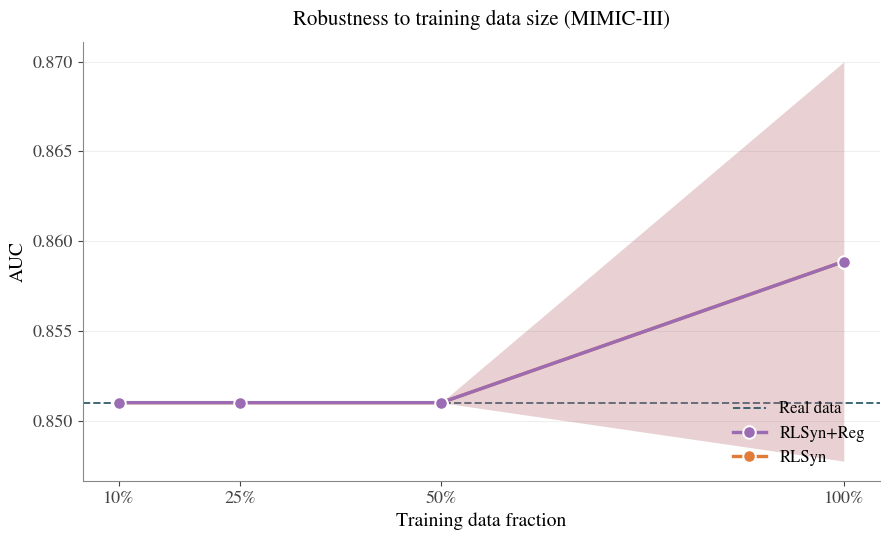

In [ ]:
# ============================================================
# Robustness to training data size — MIMIC, slide-ready
# ============================================================



import re
from pathlib import Path

RESULTS_DIR = Path("/home/nick/RL_guided/MIMIC/results")
SEEDS = [50, 51, 52]
FRACTIONS = [0.10, 0.25, 0.50, 1.00]

SENSITIVITY_METRIC_CONFIG = {
    'coef_corr':    {'label': 'Coefficient Correlation ($r$)', 'rmse': False, 'higher': True},
    'syn_model_auc': {
        'MIMIC': {'label': 'AUC',  'rmse': False, 'higher': True},
        'ACS':   {'label': 'RMSE', 'rmse': True,  'higher': False},
    },
    's2r_auc':      {'label': 'S2R AUC', 'rmse': False, 'higher': True},
    'dwd':          {'label': 'DWD',     'rmse': False, 'higher': False},
}


def parse_eval_txt(eval_path):
    """Pull all relevant metrics from one eval.txt."""
    if not eval_path.exists():
        return None
    text = eval_path.read_text()
    out = {}
    patterns = {
        'syn_model_auc': r"Syn Model AUC:\s*([0-9.]+)",
        'coef_corr':     r"Coef Correlation:\s*(-?[0-9.]+)",
        's2r_auc':       r"S2R AUC:\s*([0-9.]+)",
        'dwd':           r"DWD:\s*([0-9.]+)",
    }
    for key, pat in patterns.items():
        m = re.search(pat, text)
        out[key] = float(m.group(1)) if m else None
    return out

def build_res_by_frac(base_dir):
    res = {}
    for frac in FRACTIONS:
        res[frac] = {'unpenalized': [], 'penalized': []}
        for seed in SEEDS:
            suffix = "" if frac == 1.00 else f"_frac{frac:g}"
            unpen = parse_eval_txt(base_dir / f"{seed}{suffix}" / "eval.txt")
            pen   = parse_eval_txt(base_dir / "penalized" / f"{seed}{suffix}" / "eval.txt")
            if unpen: res[frac]['unpenalized'].append(unpen)
            if pen:   res[frac]['penalized'].append(pen)
    return res

res_mimic_by_frac = build_res_by_frac(RESULTS_DIR)


def agg(results_list, metric):
    """Mean and std across seeds for a metric."""
    vals = [r[metric] for r in results_list if r.get(metric) is not None]
    if not vals:
        return (None, None)
    return (float(np.mean(vals)), float(np.std(vals)))

def agg_rmse(results_list, metric):
    """For metrics stored as MSE — convert to RMSE."""
    vals = [np.sqrt(r[metric]) for r in results_list if r.get(metric) is not None]
    if not vals:
        return (None, None)
    return (float(np.mean(vals)), float(np.std(vals)))

METRIC_TO_BASELINE = {
    'syn_model_auc': 'real_model_auc',
    'coef_corr':     None,
    's2r_auc':       'real_s2r_auc',
    'dwd':           None,
}

DATASET_CONFIG = {
    'MIMIC': {'real_model_auc': (0.851, 0.0)},
    'ACS':   {'real_model_auc': (401.275, 0.0)},
}




import matplotlib
matplotlib.rcParams['font.family'] = 'STIXGeneral'
matplotlib.rcParams['font.serif'] = ['Times New Roman']

def plot_sensitivity_mimic_slide(res_by_frac, metric='syn_model_auc', out_path=None):
    COLOR_REAL = "#1F4E5F"
    COLOR_SYNTH = "#E07B39"
    COLOR_PEN = "#9B6BB3"

    fracs = sorted(res_by_frac.keys())
    cfg = SENSITIVITY_METRIC_CONFIG.get(metric, {})
    if isinstance(cfg.get('MIMIC'), dict):
        cfg = cfg['MIMIC']
    use_rmse = cfg.get('rmse', False)
    ylabel = cfg.get('label', metric)

    fig, ax = plt.subplots(figsize=(9, 5.5))

    # Real-data baseline first so lines sit on top
    baseline_key = METRIC_TO_BASELINE.get(metric)
    if baseline_key and DATASET_CONFIG['MIMIC'].get(baseline_key, (None,))[0] is not None:
        b_m, b_s = DATASET_CONFIG['MIMIC'][baseline_key]
        if use_rmse and b_m is not None:
            b_m = float(np.sqrt(b_m))
        ax.axhline(b_m, color=COLOR_REAL, linestyle="--", linewidth=1.4,
                    alpha=0.85, label="Real data", zorder=1)

    model_styles = {
        'penalized':   {'color': COLOR_PEN,   'label': 'RLSyn+Reg', 'zorder': 4},
        'unpenalized': {'color': COLOR_SYNTH, 'label': 'RLSyn',     'zorder': 3},
    }

    agg_fn = agg_rmse if use_rmse else agg

    for model, style in model_styles.items():
        means = [agg_fn(res_by_frac[f][model], metric)[0] for f in fracs]
        stds  = [agg_fn(res_by_frac[f][model], metric)[1] for f in fracs]
        means = np.array([m if m is not None else np.nan for m in means])
        stds  = np.array([s if s is not None and not np.isnan(s) else 0 for s in stds])

        ax.fill_between(fracs, means - stds, means + stds,
                        alpha=0.18, color=style['color'], linewidth=0,
                        zorder=style['zorder'] - 1)
        ax.plot(fracs, means, color=style['color'], linewidth=2.4,
                marker='o', markersize=9,
                markeredgecolor='white', markeredgewidth=1.4,
                label=style['label'], zorder=style['zorder'])

    ax.set_xticks(fracs)
    ax.set_xticklabels([f'{int(f*100)}%' for f in fracs], fontsize=13)
    ax.tick_params(axis='y', labelsize=13, colors="#444444")
    ax.tick_params(axis='x', colors="#444444")
    ax.set_xlabel('Training data fraction', fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.set_title('Robustness to training data size (MIMIC-III)',
                    fontsize=15, pad=12)

    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.spines["left"].set_color("#888888")
    ax.spines["bottom"].set_color("#888888")

    ax.grid(axis="y", alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.legend(loc="lower right", fontsize=12, frameon=False)

    fig.tight_layout()
    if out_path:
        plt.savefig(out_path, bbox_inches='tight', dpi=300)
    plt.show()


plot_sensitivity_mimic_slide(res_mimic_by_frac, metric='syn_model_auc', out_path='sensitivity_mimic_slide.png')

In [ ]:
res_mimic_by_frac

{0.1: {'unpenalized': [{'syn_model_auc': 0.851,
    'coef_corr': 1.0,
    's2r_auc': 0.9727,
    'dwd': 0.0},
   {'syn_model_auc': 0.851, 'coef_corr': 1.0, 's2r_auc': 0.9727, 'dwd': 0.0},
   {'syn_model_auc': 0.851, 'coef_corr': 1.0, 's2r_auc': 0.973, 'dwd': 0.0}],
  'penalized': [{'syn_model_auc': 0.851,
    'coef_corr': 1.0,
    's2r_auc': 0.9736,
    'dwd': 0.0},
   {'syn_model_auc': 0.851, 'coef_corr': 1.0, 's2r_auc': 0.9728, 'dwd': 0.0}]},
 0.25: {'unpenalized': [{'syn_model_auc': 0.851,
    'coef_corr': 1.0,
    's2r_auc': 0.9744,
    'dwd': 0.0},
   {'syn_model_auc': 0.851, 'coef_corr': 1.0, 's2r_auc': 0.9743, 'dwd': 0.0},
   {'syn_model_auc': 0.851, 'coef_corr': 1.0, 's2r_auc': 0.9713, 'dwd': 0.0}],
  'penalized': [{'syn_model_auc': 0.851,
    'coef_corr': 1.0,
    's2r_auc': 0.9721,
    'dwd': 0.0},
   {'syn_model_auc': 0.851, 'coef_corr': 1.0, 's2r_auc': 0.9727, 'dwd': 0.0},
   {'syn_model_auc': 0.851, 'coef_corr': 1.0, 's2r_auc': 0.9745, 'dwd': 0.0}]},
 0.5: {'unpenalized': 